# Pelatihan Model EmoSense-ID

Notebook ini menjalankan **Tahap 1 (membangun model)** langkah demi langkah:
pra-pemrosesan → TF-IDF → perbandingan model → **hyperparameter tuning** → pelatihan →
evaluasi → simpan artefak.

Logika yang sama tersedia sebagai skrip di `src/train.py` (jalankan `python src/train.py --tune`)
& `src/evaluate.py`. Notebook ini untuk **memahami & mendemonstrasikan** prosesnya.

> Pra-pemrosesan teks memakai `clean_text()` dari `src/preprocessing.py` — **fungsi yang sama**
> dengan yang dipakai aplikasi, agar konsisten.

In [1]:
import sys
from pathlib import Path

# Temukan root proyek baik dijalankan dari root maupun dari folder notebooks/.
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

from preprocessing import clean_text

DATA = ROOT / 'data' / 'prdect_id.csv'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)
RANDOM_STATE = 42
print('Root proyek:', ROOT)

Root proyek: /Users/imadegautama/Documents/codes/uas-nlp


## 1. Muat data
Dataset PRDECT-ID: kolom `Customer Review` (teks), `Sentiment`, `Emotion`.

In [2]:
df = pd.read_csv(DATA)
print('Jumlah ulasan:', len(df))
print('\nSentimen:\n', df['Sentiment'].value_counts())
print('\nEmosi:\n', df['Emotion'].value_counts())
df[['Customer Review', 'Sentiment', 'Emotion']].head()

Jumlah ulasan: 5400

Sentimen:
 Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emosi:
 Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


,Customer Review,Sentiment,Emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


## 2. Pra-pemrosesan teks
`clean_text()`: case folding → hapus URL/angka/simbol → hapus stopword (kata negasi
dipertahankan) → stemming Sastrawi. (Stemming ribuan ulasan butuh beberapa detik.)

In [3]:
contoh = 'Barangnya BAGUS, tapi pengirimannya TIDAK cepat!!! :('
print('ASLI  :', contoh)
print('BERSIH:', clean_text(contoh))

df['clean'] = df['Customer Review'].apply(clean_text)
df = df[df['clean'].str.len() > 0].reset_index(drop=True)
print('\nSetelah dibersihkan:', len(df), 'ulasan')
df[['clean', 'Sentiment', 'Emotion']].head()

ASLI  : Barangnya BAGUS, tapi pengirimannya TIDAK cepat!!! :(
BERSIH: barang bagus kirim tidak cepat



Setelah dibersihkan: 5398 ulasan


,clean,Sentiment,Emotion
0,alhamdulillah fungsi packaging aman respon cep...,Positive,Happy
1,barang bagus respon cepat harga saing yg,Positive,Happy
2,barang bagus fungsi seler ramah kirim cepat,Positive,Happy
3,bagus sesuai harap jual ramah trimakasih lapak,Positive,Happy
4,barang bagus emas aman fungsi,Positive,Happy


## 3. Pembagian data & representasi fitur (TF-IDF)
Split stratified 80/20 (berdasarkan Emosi agar distribusi tak seimbang terjaga). TF-IDF
di-`fit` HANYA pada data latih, lalu dipakai mentransformasi data uji (mencegah kebocoran).

In [4]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['Emotion'])
print('Latih:', len(df_train), '| Uji:', len(df_test))

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=20000, sublinear_tf=True)
X_train = vectorizer.fit_transform(df_train['clean'])
X_test = vectorizer.transform(df_test['clean'])
print('Dimensi fitur TF-IDF:', X_train.shape[1])

Latih: 4318 | Uji: 1080
Dimensi fitur TF-IDF: 3602


## 4. Bandingkan kandidat model (5-fold CV, macro-F1)
*Model selection*: membandingkan Logistic Regression, Linear SVM, dan Multinomial NB.

In [5]:
kandidat = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Linear SVM': LinearSVC(class_weight='balanced'),
    'Multinomial NB': MultinomialNB(),
}
for tugas, kolom in [('Sentimen', 'Sentiment'), ('Emosi', 'Emotion')]:
    print(f'== {tugas} ==')
    for nama, model in kandidat.items():
        skor = cross_val_score(model, X_train, df_train[kolom], cv=5, scoring='f1_macro')
        print(f'  {nama:<22}: {skor.mean():.4f} (+/- {skor.std():.4f})')

== Sentimen ==
  Logistic Regression   : 0.9402 (+/- 0.0105)
  Linear SVM            : 0.9433 (+/- 0.0088)
  Multinomial NB        : 0.9404 (+/- 0.0095)
== Emosi ==


  Logistic Regression   : 0.5870 (+/- 0.0101)
  Linear SVM            : 0.5752 (+/- 0.0069)
  Multinomial NB        : 0.4556 (+/- 0.0205)


## 5. Hyperparameter Tuning (GridSearchCV)
Berbeda dari *model selection* di atas, di sini kita mencari **kombinasi hyperparameter terbaik**
untuk Logistic Regression + TF-IDF. Memakai `Pipeline` agar TF-IDF **di-refit per-fold**
(mencegah kebocoran data). Scoring = `f1_macro` (cocok untuk kelas tak seimbang).

Tuning penuh dijalankan pada tugas **Emosi** (tersulit), lalu `C` di-tune untuk Sentimen.

In [6]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 3, 5],
    'tfidf__max_features': [10000, 20000, None],
    'clf__C': [0.1, 1, 3, 10],
}
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])
print('Tuning Emosi (', 2*3*3*4, 'kombinasi x 5 fold ) ...')
gs_emo = GridSearchCV(pipe, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
gs_emo.fit(df_train['clean'], df_train['Emotion'])
print('Best params (Emosi):', gs_emo.best_params_)
print('CV macro-F1 (Emosi):', round(gs_emo.best_score_, 4))
C_emo = gs_emo.best_params_['clf__C']

# Tune C untuk Sentimen pada fitur TF-IDF yang sudah ada (param terbaik = sama dgn vectorizer ini).
gs_sent = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    {'C': [0.1, 1, 3, 10]}, scoring='f1_macro', cv=5, n_jobs=-1)
gs_sent.fit(X_train, df_train['Sentiment'])
C_sent = gs_sent.best_params_['C']
print('\nBest C (Sentimen):', C_sent, '| CV macro-F1:', round(gs_sent.best_score_, 4))

Tuning Emosi ( 72 kombinasi x 5 fold ) ...


Best params (Emosi): {'clf__C': 1, 'tfidf__max_features': 10000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
CV macro-F1 (Emosi): 0.5847

Best C (Sentimen): 10 | CV macro-F1: 0.9447


## 6. Latih model final (pakai C hasil tuning) & simpan
**Logistic Regression** dipilih: kompetitif, punya `predict_proba` (keyakinan) dan `coef_`
(explainability). Dua classifier terpisah berbagi satu vectorizer.

In [7]:
model_sentimen = LogisticRegression(max_iter=1000, class_weight='balanced', C=C_sent).fit(X_train, df_train['Sentiment'])
model_emosi = LogisticRegression(max_iter=1000, class_weight='balanced', C=C_emo).fit(X_train, df_train['Emotion'])
print(f'C Sentimen = {C_sent} | C Emosi = {C_emo}')

joblib.dump(vectorizer, MODELS / 'tfidf_vectorizer.joblib')
joblib.dump(model_sentimen, MODELS / 'classic_sentiment.joblib')
joblib.dump(model_emosi, MODELS / 'classic_emotion.joblib')
print('Artefak tersimpan di', MODELS)

C Sentimen = 10 | C Emosi = 1
Artefak tersimpan di /Users/imadegautama/Documents/codes/uas-nlp/models


## 7. Evaluasi pada data uji
Accuracy + macro-F1 + classification_report + confusion matrix untuk tiap tugas.

===== Sentimen =====
Macro-F1: 0.9377
              precision    recall  f1-score   support

    Negative     0.9219    0.9628    0.9419       564
    Positive     0.9572    0.9109    0.9335       516

    accuracy                         0.9380      1080
   macro avg     0.9396    0.9368    0.9377      1080
weighted avg     0.9388    0.9380    0.9379      1080



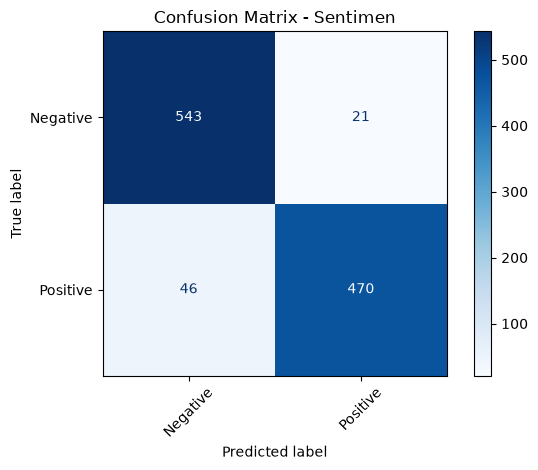

===== Emosi =====
Macro-F1: 0.6086
              precision    recall  f1-score   support

       Anger     0.4158    0.5643    0.4788       140
        Fear     0.4899    0.5272    0.5079       184
       Happy     0.8449    0.7542    0.7970       354
        Love     0.6229    0.6728    0.6469       162
     Sadness     0.6716    0.5625    0.6122       240

    accuracy                         0.6361      1080
   macro avg     0.6090    0.6162    0.6086      1080
weighted avg     0.6570    0.6361    0.6429      1080



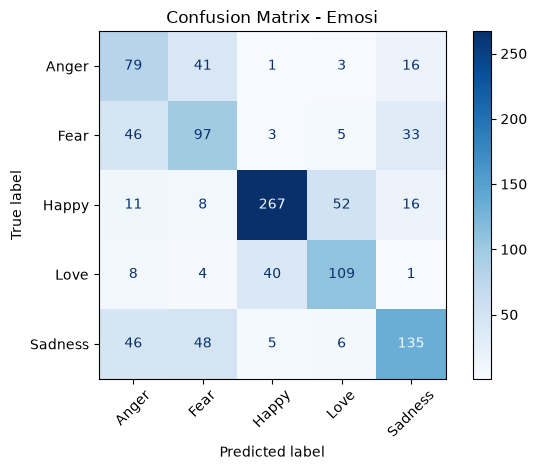

In [8]:
for tugas, kolom, model in [('Sentimen', 'Sentiment', model_sentimen), ('Emosi', 'Emotion', model_emosi)]:
    y_test = df_test[kolom]
    y_pred = model.predict(X_test)
    print(f'===== {tugas} =====')
    print('Macro-F1:', round(f1_score(y_test, y_pred, average='macro'), 4))
    print(classification_report(y_test, y_pred, digits=4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix - {tugas}')
    plt.tight_layout(); plt.show()

## Kesimpulan
- **Model selection** (sel 4) memilih Logistic Regression; **hyperparameter tuning** (sel 5)
  mencari `C` & param TF-IDF terbaik via GridSearchCV — dua hal berbeda.
- Tuning paling membantu **Sentimen** (`C=10`, akurasi uji ~0.938); **Emosi** sudah mentok di
  sekitar ~0.64 (5 kelas, tak seimbang).
- Artefak (`tfidf_vectorizer.joblib`, `classic_sentiment.joblib`, `classic_emotion.joblib`)
  dipakai langsung oleh aplikasi Streamlit, REST API, dan bot Telegram — **tanpa latih ulang**.
- Lanjutan (ABSA & lapisan AI) dibangun di atas model ini; lihat `src/absa.py` & `src/llm.py`.